# Weryfikacja najlepszych konfiguracji i porównanie topologii

Notebook realizuje cały proces:

1. wczytanie wyników dla `meeting`, `scale_free` i `complete`,
2. identyfikację konfiguracji,
3. podsumowanie trzech kandydatów dla każdej liczby wysp,
4. wybór top 1 na podstawie średniej wartości miary `best` z pięciu powtórzeń,
5. utworzenie równorzędnego zbioru porównawczego: top 1 meeting, top 1 scale-free i complete,
6. tabele opisowe i wykresy,
7. test Kruskala–Wallisa,
8. test Dunna z korektą Holma,
9. deltę Cliffa dla każdej pary topologii,
10. zapis tabel i rysunków.

Jednostką statystyczną jest jedno niezależne uruchomienie.


In [41]:
from pathlib import Path
from itertools import combinations
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

try:
    import scikit_posthocs as sp
except ImportError as exc:
    raise ImportError(
        "Brakuje pakietu scikit-posthocs. Zainstaluj go poleceniem: "
        "pip install scikit-posthocs"
    ) from exc

sns.set_theme(style="whitegrid", context="paper")

RESULTS_PATH = Path("results/best_configs_v1")
OUTPUT_PATH = Path("results/top1_comparison")
FIGURES_PATH = OUTPUT_PATH / "figures"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
ISLAND_COUNTS = [50, 100, 200, 300, 500]
ALPHA = 0.05



## 1. Wczytanie danych


In [2]:
def load_topology_files(results_path: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_path / pattern)))

    if not files:
        raise FileNotFoundError(
            f"Nie znaleziono plików zgodnych z wzorcem: {results_path / pattern}"
        )

    frames = []
    for file in files:
        frame = pd.read_csv(file)
        frame["source_file"] = os.path.basename(file)
        frames.append(frame)

    result = pd.concat(frames, ignore_index=True)
    print(f"{pattern}: {len(files)} plików, {len(result)} wierszy")
    return result


df_meeting = load_topology_files(RESULTS_PATH, "meeting*.csv")
df_scale_free = load_topology_files(RESULTS_PATH, "scale_free*.csv")
df_complete = load_topology_files(RESULTS_PATH, "complete*.csv")


meeting*.csv: 5 plików, 75 wierszy
scale_free*.csv: 5 plików, 75 wierszy
complete*.csv: 5 plików, 25 wierszy


In [3]:
REQUIRED_COMMON = {
    "topology", "number_of_islands", "best", "average"
}

def validate_columns(df: pd.DataFrame, required: set[str], name: str) -> None:
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{name}: brakujące kolumny: {sorted(missing)}")


validate_columns(
    df_meeting,
    REQUIRED_COMMON | {"z_star", "r0", "r1", "gamma", "n_steps"},
    "meeting",
)
validate_columns(
    df_scale_free,
    REQUIRED_COMMON | {"m0", "m"},
    "scale_free",
)
validate_columns(df_complete, REQUIRED_COMMON, "complete")

for name, df in {
    "meeting": df_meeting,
    "scale_free": df_scale_free,
    "complete": df_complete,
}.items():
    print(name, sorted(df["number_of_islands"].unique()))


meeting [50, 100, 200, 300, 500]
scale_free [50, 100, 200, 300, 500]
complete [50, 100, 200, 300, 500]


## 2. Identyfikatory konfiguracji


In [4]:
def add_config_id(df: pd.DataFrame, config_cols: list[str]) -> pd.DataFrame:
    result = df.copy()

    missing = set(config_cols) - set(result.columns)
    if missing:
        raise ValueError(f"Brak kolumn konfiguracji: {sorted(missing)}")

    result["config_id"] = (
        result[config_cols]
        .astype(str)
        .agg("|".join, axis=1)
    )
    return result


meeting_config_cols = [
    "number_of_islands",
    "z_star",
    "r0",
    "r1",
    "gamma",
    "n_steps",
]

scale_free_config_cols = [
    "number_of_islands",
    "m0",
    "m",
]

# Jeśli migration_interval różni się między konfiguracjami,
# dodaj tę kolumnę do odpowiednich list powyżej.
df_meeting = add_config_id(df_meeting, meeting_config_cols)
df_scale_free = add_config_id(df_scale_free, scale_free_config_cols)


## 3. Podsumowanie konfiguracji


In [5]:
def summarize_configs(
    df: pd.DataFrame,
    parameter_cols: list[str],
) -> pd.DataFrame:
    group_cols = [
        "topology",
        "number_of_islands",
        "config_id",
        *parameter_cols,
    ]

    return (
        df.groupby(group_cols, as_index=False)
        .agg(
            n_runs=("best", "size"),
            mean_best=("best", "mean"),
            std_best=("best", "std"),
            median_best=("best", "median"),
            min_best=("best", "min"),
            max_best=("best", "max"),
            mean_average=("average", "mean"),
            std_average=("average", "std"),
            median_average=("average", "median"),
            min_average=("average", "min"),
            max_average=("average", "max"),
        )
    )


meeting_summary = summarize_configs(
    df_meeting,
    ["z_star", "r0", "r1", "gamma", "n_steps"],
)

scale_free_summary = summarize_configs(
    df_scale_free,
    ["m0", "m"],
)

display(meeting_summary.head())
display(scale_free_summary.head())


,topology,number_of_islands,config_id,z_star,r0,r1,gamma,n_steps,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,meeting,50,50|10|0.0005|1.0|0.001|500,10,0.0005,1.0,0.001,500,5,252.578908,21.201461,262.830309,229.618289,271.501903,280.947131,22.178668,289.250320,256.821691,301.599155
1,meeting,50,50|5|0.001|1.0|0.001|500,5,0.0010,1.0,0.001,500,5,239.232468,12.134086,236.735301,226.965400,259.408667,273.992568,15.920144,279.712695,245.895347,285.403785
2,meeting,50,50|5|0.001|2.0|0.001|500,5,0.0010,2.0,0.001,500,5,247.798513,12.832529,242.389441,236.645294,266.977209,266.966271,16.267604,257.558162,253.330115,292.327823
3,meeting,100,100|10|0.0005|1.0|0.001|500,10,0.0005,1.0,0.001,500,5,161.934634,9.688102,158.388080,152.816982,175.738106,202.206421,9.067233,196.517710,194.970053,215.748396
4,meeting,100,100|10|0.001|1.0|0.001|500,10,0.0010,1.0,0.001,500,5,159.686322,14.112712,153.137396,145.992760,178.323809,203.062983,19.205389,194.114270,185.255702,226.908799


,topology,number_of_islands,config_id,m0,m,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,scale_free,50,50|12|11,12,11,5,241.718595,8.773415,242.815296,227.303990,251.222278,271.032685,10.826416,277.063132,252.350627,277.663332
1,scale_free,50,50|12|8,12,8,5,258.610477,19.018243,263.318067,225.490799,272.357989,286.822299,22.801755,295.522351,246.396004,301.758976
2,scale_free,50,50|12|9,12,9,5,230.262622,17.438622,237.923236,204.120437,248.584277,252.093164,18.133591,249.423133,227.981058,274.965411
3,scale_free,100,100|20|13,20,13,5,139.742250,9.312970,139.555531,127.277825,151.675449,206.053124,15.075100,212.740723,179.184287,214.540411
4,scale_free,100,100|20|15,20,15,5,145.285548,7.080622,147.368166,136.608439,154.127461,200.646857,8.447857,202.108526,189.248335,211.984340


## 4. Trzy najlepsze konfiguracje

Konfiguracje są porządkowane według:

1. średniej wartości `best`,
2. mediany `best`,
3. średniej wartości `average`.

Dwa ostatnie kryteria pełnią rolę pomocniczą przy bardzo zbliżonych wynikach.


In [6]:
def select_top_k_configs(
    summary: pd.DataFrame,
    k: int = 3,
) -> pd.DataFrame:
    return (
        summary
        .sort_values(
            [
                "number_of_islands",
                "mean_best",
                "median_best",
                "mean_average",
            ]
        )
        .groupby("number_of_islands", as_index=False, group_keys=False)
        .head(k)
        .reset_index(drop=True)
    )


top3_meeting_summary = select_top_k_configs(meeting_summary, k=3)
top3_scale_free_summary = select_top_k_configs(scale_free_summary, k=3)

display(top3_meeting_summary)
display(top3_scale_free_summary)

top3_meeting_summary.to_csv(
    OUTPUT_PATH / "top3_meeting_summary.csv", index=False
)
top3_scale_free_summary.to_csv(
    OUTPUT_PATH / "top3_scale_free_summary.csv", index=False
)


,topology,number_of_islands,config_id,z_star,r0,r1,gamma,n_steps,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,meeting,50,50|5|0.001|1.0|0.001|500,5,0.00100,1.0,0.001,500,5,239.232468,12.134086,236.735301,226.965400,259.408667,273.992568,15.920144,279.712695,245.895347,285.403785
1,meeting,50,50|5|0.001|2.0|0.001|500,5,0.00100,2.0,0.001,500,5,247.798513,12.832529,242.389441,236.645294,266.977209,266.966271,16.267604,257.558162,253.330115,292.327823
2,meeting,50,50|10|0.0005|1.0|0.001|500,10,0.00050,1.0,0.001,500,5,252.578908,21.201461,262.830309,229.618289,271.501903,280.947131,22.178668,289.250320,256.821691,301.599155
3,meeting,100,100|10|0.001|2.0|0.001|500,10,0.00100,2.0,0.001,500,5,155.460940,10.934231,152.742230,145.672172,171.674625,194.164416,16.833833,191.792073,176.885986,215.552298
4,meeting,100,100|10|0.001|1.0|0.001|500,10,0.00100,1.0,0.001,500,5,159.686322,14.112712,153.137396,145.992760,178.323809,203.062983,19.205389,194.114270,185.255702,226.908799
5,meeting,100,100|10|0.0005|1.0|0.001|500,10,0.00050,1.0,0.001,500,5,161.934634,9.688102,158.388080,152.816982,175.738106,202.206421,9.067233,196.517710,194.970053,215.748396
6,meeting,200,200|10|0.001|2.0|0.001|500,10,0.00100,2.0,0.001,500,5,111.927751,3.674862,113.589917,105.709522,115.053862,135.956438,4.904240,133.925410,133.287894,144.715462
7,meeting,200,200|5|0.001|2.0|0.001|500,5,0.00100,2.0,0.001,500,5,117.764720,6.852201,119.187385,107.222019,124.685609,147.827986,9.613278,144.972258,138.562651,161.436442
8,meeting,200,200|5|0.0005|2.0|0.001|500,5,0.00050,2.0,0.001,500,5,121.554747,7.556155,121.503731,109.326765,128.911084,147.253108,6.892753,145.927045,137.141807,154.770394
9,meeting,300,300|10|0.001|2.0|0.005|1000,10,0.00100,2.0,0.005,1000,5,80.891533,5.400148,80.128208,75.975925,88.879210,105.646160,6.156441,104.486511,99.245399,113.058927


,topology,number_of_islands,config_id,m0,m,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,scale_free,50,50|12|9,12,9,5,230.262622,17.438622,237.923236,204.120437,248.584277,252.093164,18.133591,249.423133,227.981058,274.965411
1,scale_free,50,50|12|11,12,11,5,241.718595,8.773415,242.815296,227.303990,251.222278,271.032685,10.826416,277.063132,252.350627,277.663332
2,scale_free,50,50|12|8,12,8,5,258.610477,19.018243,263.318067,225.490799,272.357989,286.822299,22.801755,295.522351,246.396004,301.758976
3,scale_free,100,100|20|16,20,16,5,136.432096,11.942419,129.483435,126.880463,154.129889,188.261924,11.339419,183.758137,176.294838,206.108014
4,scale_free,100,100|20|13,20,13,5,139.742250,9.312970,139.555531,127.277825,151.675449,206.053124,15.075100,212.740723,179.184287,214.540411
5,scale_free,100,100|20|15,20,15,5,145.285548,7.080622,147.368166,136.608439,154.127461,200.646857,8.447857,202.108526,189.248335,211.984340
6,scale_free,200,200|12|11,12,11,5,76.414904,5.610225,79.256173,69.568359,81.772324,148.318257,9.558900,151.375686,134.974849,158.129228
7,scale_free,200,200|15|15,15,15,5,76.476043,4.023665,77.588128,70.087553,80.999886,142.482966,10.075900,146.951756,129.653547,154.245161
8,scale_free,200,200|15|14,15,14,5,80.302691,6.801776,80.315462,71.164097,90.291510,149.519259,6.530779,152.691503,139.132327,154.768352
9,scale_free,300,300|15|15,15,15,5,45.463471,4.411655,45.787259,39.963290,50.262052,124.410201,4.248353,124.019410,118.295679,129.625247


In [7]:
top3_scale_free_summary

,topology,number_of_islands,config_id,m0,m,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,scale_free,50,50|12|9,12,9,5,230.262622,17.438622,237.923236,204.120437,248.584277,252.093164,18.133591,249.423133,227.981058,274.965411
1,scale_free,50,50|12|11,12,11,5,241.718595,8.773415,242.815296,227.303990,251.222278,271.032685,10.826416,277.063132,252.350627,277.663332
2,scale_free,50,50|12|8,12,8,5,258.610477,19.018243,263.318067,225.490799,272.357989,286.822299,22.801755,295.522351,246.396004,301.758976
3,scale_free,100,100|20|16,20,16,5,136.432096,11.942419,129.483435,126.880463,154.129889,188.261924,11.339419,183.758137,176.294838,206.108014
4,scale_free,100,100|20|13,20,13,5,139.742250,9.312970,139.555531,127.277825,151.675449,206.053124,15.075100,212.740723,179.184287,214.540411
5,scale_free,100,100|20|15,20,15,5,145.285548,7.080622,147.368166,136.608439,154.127461,200.646857,8.447857,202.108526,189.248335,211.984340
6,scale_free,200,200|12|11,12,11,5,76.414904,5.610225,79.256173,69.568359,81.772324,148.318257,9.558900,151.375686,134.974849,158.129228
7,scale_free,200,200|15|15,15,15,5,76.476043,4.023665,77.588128,70.087553,80.999886,142.482966,10.075900,146.951756,129.653547,154.245161
8,scale_free,200,200|15|14,15,14,5,80.302691,6.801776,80.315462,71.164097,90.291510,149.519259,6.530779,152.691503,139.132327,154.768352
9,scale_free,300,300|15|15,15,15,5,45.463471,4.411655,45.787259,39.963290,50.262052,124.410201,4.248353,124.019410,118.295679,129.625247


In [8]:
top3_meeting_summary

,topology,number_of_islands,config_id,z_star,r0,r1,gamma,n_steps,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,meeting,50,50|5|0.001|1.0|0.001|500,5,0.00100,1.0,0.001,500,5,239.232468,12.134086,236.735301,226.965400,259.408667,273.992568,15.920144,279.712695,245.895347,285.403785
1,meeting,50,50|5|0.001|2.0|0.001|500,5,0.00100,2.0,0.001,500,5,247.798513,12.832529,242.389441,236.645294,266.977209,266.966271,16.267604,257.558162,253.330115,292.327823
2,meeting,50,50|10|0.0005|1.0|0.001|500,10,0.00050,1.0,0.001,500,5,252.578908,21.201461,262.830309,229.618289,271.501903,280.947131,22.178668,289.250320,256.821691,301.599155
3,meeting,100,100|10|0.001|2.0|0.001|500,10,0.00100,2.0,0.001,500,5,155.460940,10.934231,152.742230,145.672172,171.674625,194.164416,16.833833,191.792073,176.885986,215.552298
4,meeting,100,100|10|0.001|1.0|0.001|500,10,0.00100,1.0,0.001,500,5,159.686322,14.112712,153.137396,145.992760,178.323809,203.062983,19.205389,194.114270,185.255702,226.908799
5,meeting,100,100|10|0.0005|1.0|0.001|500,10,0.00050,1.0,0.001,500,5,161.934634,9.688102,158.388080,152.816982,175.738106,202.206421,9.067233,196.517710,194.970053,215.748396
6,meeting,200,200|10|0.001|2.0|0.001|500,10,0.00100,2.0,0.001,500,5,111.927751,3.674862,113.589917,105.709522,115.053862,135.956438,4.904240,133.925410,133.287894,144.715462
7,meeting,200,200|5|0.001|2.0|0.001|500,5,0.00100,2.0,0.001,500,5,117.764720,6.852201,119.187385,107.222019,124.685609,147.827986,9.613278,144.972258,138.562651,161.436442
8,meeting,200,200|5|0.0005|2.0|0.001|500,5,0.00050,2.0,0.001,500,5,121.554747,7.556155,121.503731,109.326765,128.911084,147.253108,6.892753,145.927045,137.141807,154.770394
9,meeting,300,300|10|0.001|2.0|0.005|1000,10,0.00100,2.0,0.005,1000,5,80.891533,5.400148,80.128208,75.975925,88.879210,105.646160,6.156441,104.486511,99.245399,113.058927


## 5. Weryfikacja top 3 wewnątrz każdej topologii

Ta część porównuje trzy konfiguracje kandydackie osobno dla każdej liczby wysp.
Nie jest to jeszcze główne porównanie topologii.


In [9]:
def get_runs_for_selected_configs(
    runs: pd.DataFrame,
    selected_summary: pd.DataFrame,
) -> pd.DataFrame:
    selected_ids = selected_summary[
        ["number_of_islands", "config_id"]
    ].drop_duplicates()

    return runs.merge(
        selected_ids,
        on=["number_of_islands", "config_id"],
        how="inner",
        validate="many_to_one",
    )


top3_meeting_runs = get_runs_for_selected_configs(
    df_meeting, top3_meeting_summary
)
top3_scale_free_runs = get_runs_for_selected_configs(
    df_scale_free, top3_scale_free_summary
)

print("Meeting:", top3_meeting_runs.groupby(
    ["number_of_islands", "config_id"]
).size().to_dict())

print("Scale-free:", top3_scale_free_runs.groupby(
    ["number_of_islands", "config_id"]
).size().to_dict())


Meeting: {(50, '50|10|0.0005|1.0|0.001|500'): 5, (50, '50|5|0.001|1.0|0.001|500'): 5, (50, '50|5|0.001|2.0|0.001|500'): 5, (100, '100|10|0.0005|1.0|0.001|500'): 5, (100, '100|10|0.001|1.0|0.001|500'): 5, (100, '100|10|0.001|2.0|0.001|500'): 5, (200, '200|10|0.001|2.0|0.001|500'): 5, (200, '200|5|0.0005|2.0|0.001|500'): 5, (200, '200|5|0.001|2.0|0.001|500'): 5, (300, '300|10|0.00025|2.0|0.005|1000'): 5, (300, '300|10|0.001|1.0|0.001|500'): 5, (300, '300|10|0.001|2.0|0.005|1000'): 5, (500, '500|10|0.0005|1.0|0.005|1000'): 5, (500, '500|10|0.001|1.0|0.001|500'): 5, (500, '500|10|0.001|1.0|0.005|1000'): 5}
Scale-free: {(50, '50|12|11'): 5, (50, '50|12|8'): 5, (50, '50|12|9'): 5, (100, '100|20|13'): 5, (100, '100|20|15'): 5, (100, '100|20|16'): 5, (200, '200|12|11'): 5, (200, '200|15|14'): 5, (200, '200|15|15'): 5, (300, '300|15|15'): 5, (300, '300|8|7'): 5, (300, '300|8|8'): 5, (500, '500|15|14'): 5, (500, '500|20|18'): 5, (500, '500|20|19'): 5}


In [10]:
def compare_candidate_configs(
    runs: pd.DataFrame,
    topology_name: str,
    alpha: float = 0.05,
) -> tuple[pd.DataFrame, dict[int, pd.DataFrame]]:
    global_rows = []
    dunn_tables = {}

    for islands, subset in runs.groupby("number_of_islands"):
        groups = [
            group["best"].to_numpy()
            for _, group in subset.groupby("config_id")
        ]

        if len(groups) < 2:
            continue

        H, p_value = kruskal(*groups)

        global_rows.append({
            "topology": topology_name,
            "number_of_islands": islands,
            "H": H,
            "p_value": p_value,
            "significant": p_value < alpha,
        })

        if p_value < alpha:
            dunn_tables[int(islands)] = sp.posthoc_dunn(
                subset,
                val_col="best",
                group_col="config_id",
                p_adjust="holm",
            )

    return pd.DataFrame(global_rows), dunn_tables


meeting_candidate_tests, meeting_candidate_dunn = compare_candidate_configs(
    top3_meeting_runs, "meeting", ALPHA
)
scale_candidate_tests, scale_candidate_dunn = compare_candidate_configs(
    top3_scale_free_runs, "scale_free", ALPHA
)

display(meeting_candidate_tests)
display(scale_candidate_tests)


,topology,number_of_islands,H,p_value,significant
0,meeting,50,1.522719,0.467031,False
1,meeting,100,1.280000,0.527292,False
2,meeting,200,4.756989,0.092690,False
3,meeting,300,4.380000,0.111917,False
4,meeting,500,4.355556,0.113293,False


,topology,number_of_islands,H,p_value,significant
0,scale_free,50,5.469767,0.064902,False
1,scale_free,100,1.940000,0.379083,False
2,scale_free,200,1.340000,0.511709,False
3,scale_free,300,8.074419,0.017647,True
4,scale_free,500,2.223971,0.328905,False


## 6. Wybór top 1 dla każdej liczby wysp

Top 1 jest wybierana osobno dla każdej topologii i każdej liczby wysp.
Podstawowym kryterium jest najniższa średnia wartość `best` z powtórzeń.


In [11]:
top1_meeting_summary = select_top_k_configs(meeting_summary, k=1)
top1_scale_free_summary = select_top_k_configs(scale_free_summary, k=1)

top1_meeting_runs = get_runs_for_selected_configs(
    df_meeting, top1_meeting_summary
)
top1_scale_free_runs = get_runs_for_selected_configs(
    df_scale_free, top1_scale_free_summary
)

display(top1_meeting_summary)
display(top1_scale_free_summary)

top1_meeting_summary.to_csv(
    OUTPUT_PATH / "selected_top1_meeting.csv", index=False
)
top1_scale_free_summary.to_csv(
    OUTPUT_PATH / "selected_top1_scale_free.csv", index=False
)


,topology,number_of_islands,config_id,z_star,r0,r1,gamma,n_steps,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,meeting,50,50|5|0.001|1.0|0.001|500,5,0.0010,1.0,0.001,500,5,239.232468,12.134086,236.735301,226.965400,259.408667,273.992568,15.920144,279.712695,245.895347,285.403785
1,meeting,100,100|10|0.001|2.0|0.001|500,10,0.0010,2.0,0.001,500,5,155.460940,10.934231,152.742230,145.672172,171.674625,194.164416,16.833833,191.792073,176.885986,215.552298
2,meeting,200,200|10|0.001|2.0|0.001|500,10,0.0010,2.0,0.001,500,5,111.927751,3.674862,113.589917,105.709522,115.053862,135.956438,4.904240,133.925410,133.287894,144.715462
3,meeting,300,300|10|0.001|2.0|0.005|1000,10,0.0010,2.0,0.005,1000,5,80.891533,5.400148,80.128208,75.975925,88.879210,105.646160,6.156441,104.486511,99.245399,113.058927
4,meeting,500,500|10|0.0005|1.0|0.005|1000,10,0.0005,1.0,0.005,1000,5,48.784184,1.536924,48.553628,47.183104,50.902658,62.258990,0.939375,62.138087,61.446657,63.818691


,topology,number_of_islands,config_id,m0,m,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,scale_free,50,50|12|9,12,9,5,230.262622,17.438622,237.923236,204.120437,248.584277,252.093164,18.133591,249.423133,227.981058,274.965411
1,scale_free,100,100|20|16,20,16,5,136.432096,11.942419,129.483435,126.880463,154.129889,188.261924,11.339419,183.758137,176.294838,206.108014
2,scale_free,200,200|12|11,12,11,5,76.414904,5.610225,79.256173,69.568359,81.772324,148.318257,9.558900,151.375686,134.974849,158.129228
3,scale_free,300,300|15|15,15,15,5,45.463471,4.411655,45.787259,39.963290,50.262052,124.410201,4.248353,124.019410,118.295679,129.625247
4,scale_free,500,500|20|19,20,19,5,21.118891,2.659887,22.544211,18.253427,23.914107,83.752959,1.490149,83.018504,82.498808,85.411672


In [12]:
def check_run_counts(
    df: pd.DataFrame,
    expected_runs: int = 5,
) -> pd.DataFrame:
    counts = (
        df.groupby(["topology", "number_of_islands"])
        .size()
        .rename("n_runs")
        .reset_index()
    )
    counts["expected"] = expected_runs
    counts["ok"] = counts["n_runs"] == expected_runs
    return counts


main_runs = pd.concat(
    [
        top1_meeting_runs,
        top1_scale_free_runs,
        df_complete,
    ],
    ignore_index=True,
    sort=False,
)

run_counts = check_run_counts(main_runs, expected_runs=5)
display(run_counts)

if not run_counts["ok"].all():
    print(
        "UWAGA: nie wszystkie grupy mają dokładnie pięć uruchomień. "
        "Sprawdź pliki i identyfikatory konfiguracji."
    )


,topology,number_of_islands,n_runs,expected,ok
0,complete,50,5,5,True
1,complete,100,5,5,True
2,complete,200,5,5,True
3,complete,300,5,5,True
4,complete,500,5,5,True
5,meeting,50,5,5,True
6,meeting,100,5,5,True
7,meeting,200,5,5,True
8,meeting,300,5,5,True
9,meeting,500,5,5,True


## 7. Główna tabela opisowa: top 1 vs complete


In [13]:
def summarize_main_comparison(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["number_of_islands", "topology"], as_index=False)
        .agg(
            n_runs=("best", "size"),
            mean_best=("best", "mean"),
            std_best=("best", "std"),
            median_best=("best", "median"),
            min_best=("best", "min"),
            max_best=("best", "max"),
            mean_average=("average", "mean"),
            std_average=("average", "std"),
            median_average=("average", "median"),
            min_average=("average", "min"),
            max_average=("average", "max"),
        )
        .sort_values(["number_of_islands", "topology"])
    )


main_summary = summarize_main_comparison(main_runs)
display(main_summary.round(2))

main_summary.to_csv(
    OUTPUT_PATH / "top1_topology_comparison_summary.csv",
    index=False,
)


,number_of_islands,topology,n_runs,mean_best,std_best,median_best,min_best,max_best,mean_average,std_average,median_average,min_average,max_average
0,50,complete,5,238.24,2.27,239.33,235.78,240.16,269.21,2.02,269.89,265.70,270.73
1,50,meeting,5,239.23,12.13,236.74,226.97,259.41,273.99,15.92,279.71,245.90,285.40
2,50,scale_free,5,230.26,17.44,237.92,204.12,248.58,252.09,18.13,249.42,227.98,274.97
3,100,complete,5,143.73,7.96,139.62,137.14,152.62,195.64,5.80,195.44,188.74,202.25
4,100,meeting,5,155.46,10.93,152.74,145.67,171.67,194.16,16.83,191.79,176.89,215.55
5,100,scale_free,5,136.43,11.94,129.48,126.88,154.13,188.26,11.34,183.76,176.29,206.11
6,200,complete,5,99.55,2.32,100.54,95.92,101.34,145.87,4.23,147.73,139.42,150.17
7,200,meeting,5,111.93,3.67,113.59,105.71,115.05,135.96,4.90,133.93,133.29,144.72
8,200,scale_free,5,76.41,5.61,79.26,69.57,81.77,148.32,9.56,151.38,134.97,158.13
9,300,complete,5,75.33,9.45,70.23,65.65,87.39,102.36,21.58,101.68,82.31,137.12


## 8. Wykresy głównego porównania


/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/2996614261.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topology_labels, fontsize=18)
/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/2996614261.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topology_labels, fontsize=18)
/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/2996614261.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topology_labels, fontsize=18)
/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/2996614261.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

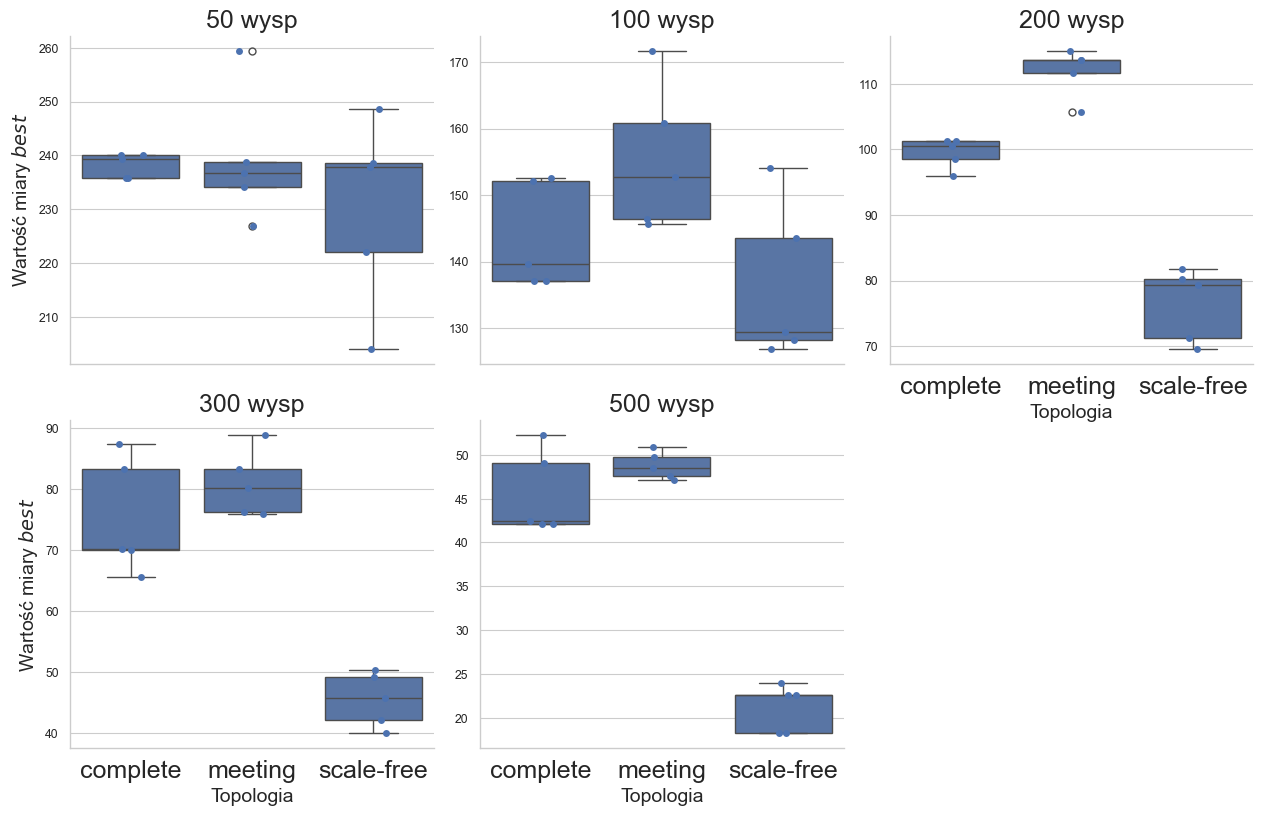

In [46]:
topology_order = ["complete", "meeting", "scale_free"]
topology_labels = ["complete", "meeting", "scale-free"]

g = sns.catplot(
    data=main_runs,
    x="topology",
    y="best",
    col="number_of_islands",
    col_wrap=3,
    order=topology_order,
    kind="box",
    sharey=False,
    height=4,
    aspect=1.05,
)

g.set_axis_labels(
    "Topologia",
    r"Wartość miary $\mathit{best}$",
    size = 14
)

g.set_titles("{col_name} wysp", size=18)

for i, ax in enumerate(g.axes.flat):
    subset_n = int(ax.get_title().split()[0])
    subset = main_runs[main_runs["number_of_islands"] == subset_n]

    sns.stripplot(
        data=subset,
        x="topology",
        y="best",
        order=topology_order,
        ax=ax,
        jitter=0.12,
        size=5,


    )

    ax.set_xticklabels(topology_labels, fontsize=18)

    if i % 3 == 0:
        ax.set_ylabel(
            r"Wartość miary $\mathit{best}$",
            fontsize=14
        )
    else:
        ax.set_ylabel("")

g.fig.savefig(
    FIGURES_PATH / "best_boxplots_top1.pdf",
    bbox_inches="tight",
)

plt.show()

In [40]:
g.set_axis_labels(
    "Topologia",
    r"Wartość miary $\mathit{best}$",
    size = 16
)

g.set_titles("{col_name} wysp", size=18)

for i, ax in enumerate(g.axes.flat):
    subset_n = int(ax.get_title().split()[0])
    subset = main_runs[main_runs["number_of_islands"] == subset_n]

    sns.stripplot(
        data=subset,
        x="topology",
        y="best",
        order=topology_order,
        ax=ax,
        jitter=0.12,
        size=5,
        color="tab:blue",
    )

    ax.set_xticklabels(topology_labels, fontsize=18)
    #ax.tick_params(axis="y", labelsize=11)

    if i % 3 == 0:
        ax.set_ylabel(
            r"Wartość miary $\mathit{best}$",
            fontsize=16

        )
    else:
        ax.set_ylabel("")

g.fig.savefig(
FIGURES_PATH / "best_boxplots_top1.pdf",
bbox_inches="tight")

plt.show()

/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/3496945107.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topology_labels, fontsize=18)
/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/3496945107.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topology_labels, fontsize=18)
/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/3496945107.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topology_labels, fontsize=18)
/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_28299/3496945107.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

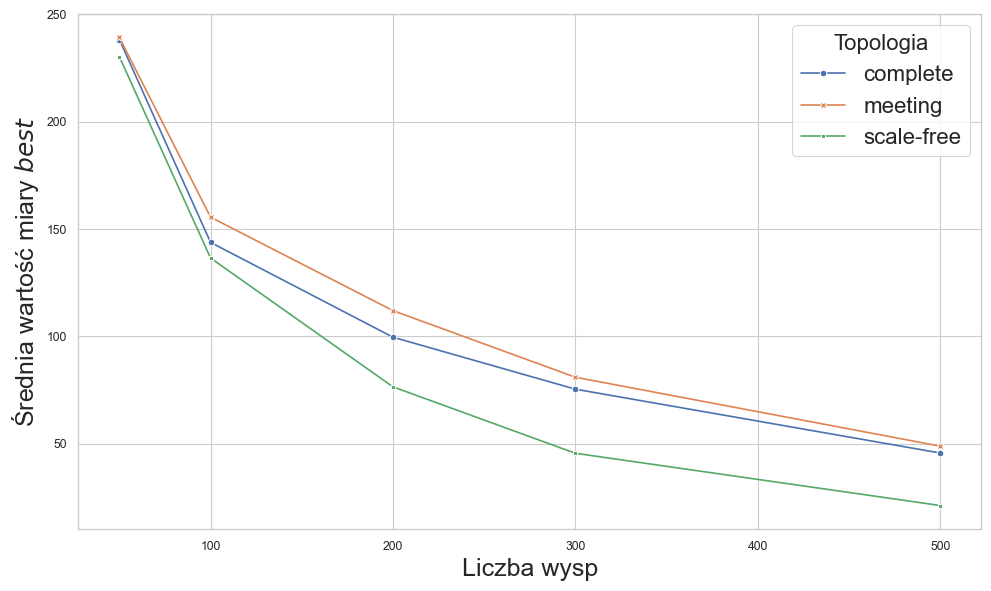

In [39]:
plot_data = main_summary.copy()

plot_data["topology_plot"] = plot_data["topology"].replace({
    "scale_free": "scale-free"
})

topology_order_plot = ["complete", "meeting", "scale-free"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=plot_data,
    x="number_of_islands",
    y="mean_best",
    hue="topology_plot",
    style="topology_plot",
    markers=True,
    dashes=False,
    hue_order=topology_order_plot,
    style_order=topology_order_plot,
    ax=ax,
)

ax.set_xlabel("Liczba wysp", size = 18)
ax.set_ylabel(r"Średnia wartość miary $\mathit{best}$", size = 18)
ax.legend(
    title="Topologia",
    fontsize=16,
    title_fontsize=16
)

fig.tight_layout()

fig.savefig(
    FIGURES_PATH / "mean_best_by_islands_top1.pdf",
    bbox_inches="tight",
)

plt.show()

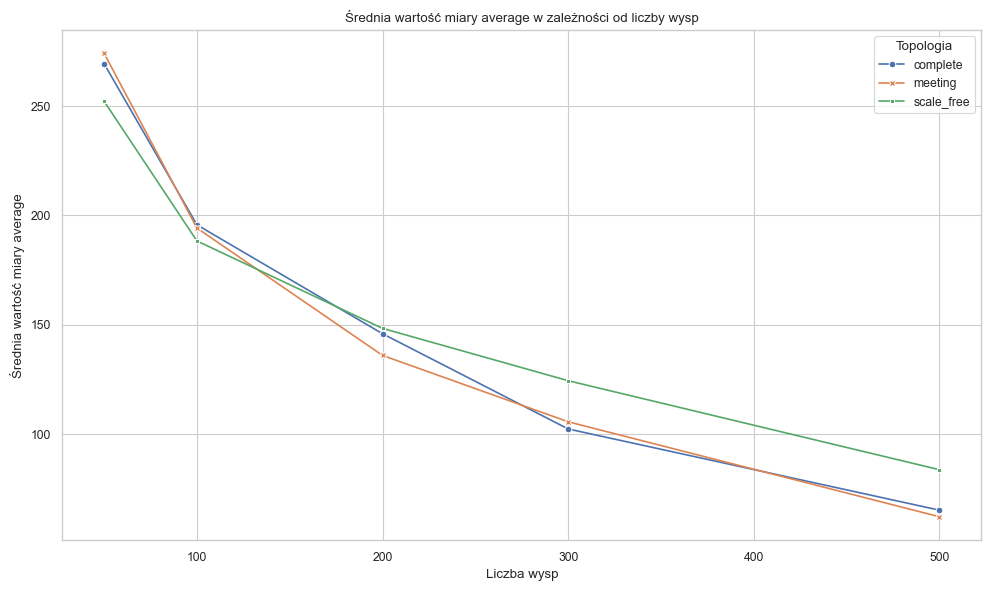

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=main_summary,
    x="number_of_islands",
    y="mean_average",
    hue="topology",
    style="topology",
    markers=True,
    dashes=False,
    hue_order=topology_order,
    style_order=topology_order,
    ax=ax,
)

ax.set_title(
    "Średnia wartość miary average w zależności od liczby wysp"
)
ax.set_xlabel("Liczba wysp")
ax.set_ylabel("Średnia wartość miary average")
ax.legend(title="Topologia")

fig.tight_layout()
fig.savefig(
    FIGURES_PATH / "mean_average_by_islands_top1.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


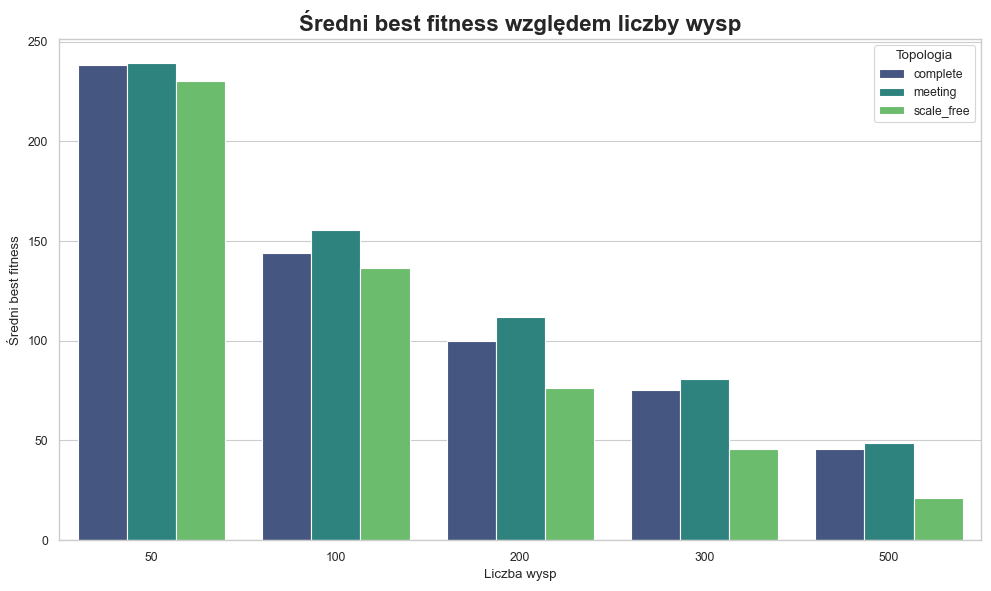

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=main_summary,
    x="number_of_islands",
    y="mean_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

## 9. Delta Cliffa

Znak delty zależy od kolejności grup:

- wartość ujemna oznacza, że pierwsza topologia ma zwykle niższe wartości `best`,
- wartość dodatnia oznacza, że druga topologia ma zwykle niższe wartości `best`.

Ponieważ niższa wartość funkcji celu jest lepsza, ujemna delta przemawia na korzyść pierwszej topologii.


In [18]:
def cliffs_delta(x, y) -> float:
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) == 0 or len(y) == 0:
        return np.nan

    greater = sum(x_i > y_j for x_i in x for y_j in y)
    lower = sum(x_i < y_j for x_i in x for y_j in y)

    return (greater - lower) / (len(x) * len(y))


def cliff_magnitude(delta: float) -> str:
    value = abs(delta)

    if value < 0.147:
        return "pomijalny"
    if value < 0.33:
        return "mały"
    if value < 0.474:
        return "średni"
    return "duży"


## 10. Kruskal–Wallis, Dunn–Holm i delta Cliffa


In [19]:
def analyze_topologies_for_island_count(
    df: pd.DataFrame,
    island_count: int,
    alpha: float = 0.05,
):
    subset = df[df["number_of_islands"] == island_count].copy()

    topology_groups = {
        topology: group["best"].to_numpy()
        for topology, group in subset.groupby("topology")
    }

    if len(topology_groups) != 3:
        raise ValueError(
            f"{island_count}: oczekiwano 3 topologii, "
            f"otrzymano {list(topology_groups)}"
        )

    H, p_value = kruskal(*topology_groups.values())

    dunn = sp.posthoc_dunn(
        subset,
        val_col="best",
        group_col="topology",
        p_adjust="holm",
    )

    cliff_rows = []
    for first, second in combinations(sorted(topology_groups), 2):
        delta = cliffs_delta(
            topology_groups[first],
            topology_groups[second],
        )

        cliff_rows.append({
            "number_of_islands": island_count,
            "topology_1": first,
            "topology_2": second,
            "delta": delta,
            "magnitude": cliff_magnitude(delta),
        })

    global_result = {
        "number_of_islands": island_count,
        "H": H,
        "p_value": p_value,
        "significant": p_value < alpha,
    }

    return global_result, dunn, pd.DataFrame(cliff_rows)


In [20]:
global_results = []
cliff_results = []
dunn_results = {}

for islands in sorted(main_runs["number_of_islands"].unique()):
    global_result, dunn, cliffs = analyze_topologies_for_island_count(
        main_runs,
        int(islands),
        ALPHA,
    )

    global_results.append(global_result)
    cliff_results.append(cliffs)
    dunn_results[int(islands)] = dunn

global_results_df = pd.DataFrame(global_results)
cliff_results_df = pd.concat(cliff_results, ignore_index=True)

display(global_results_df)
display(cliff_results_df)

global_results_df.to_csv(
    OUTPUT_PATH / "kruskal_wallis_top1.csv",
    index=False,
)
cliff_results_df.to_csv(
    OUTPUT_PATH / "cliffs_delta_top1.csv",
    index=False,
)

for islands, table in dunn_results.items():
    table.to_csv(
        OUTPUT_PATH / f"dunn_holm_top1_{islands}_islands.csv"
    )


,number_of_islands,H,p_value,significant
0,50,0.863082,0.649507,False
1,100,5.369589,0.068235,False
2,200,12.544803,0.001888,True
3,300,9.780000,0.007521,True
4,500,9.797496,0.007456,True


,number_of_islands,topology_1,topology_2,delta,magnitude
0,50,complete,meeting,0.28,mały
1,50,complete,scale_free,0.28,mały
2,50,meeting,scale_free,0.20,mały
3,100,complete,meeting,-0.68,duży
4,100,complete,scale_free,0.36,średni
5,100,meeting,scale_free,0.76,duży
6,200,complete,meeting,-1.00,duży
7,200,complete,scale_free,1.00,duży
8,200,meeting,scale_free,1.00,duży
9,300,complete,meeting,-0.36,średni


In [21]:
for islands in sorted(dunn_results):
    row = global_results_df[
        global_results_df["number_of_islands"] == islands
    ].iloc[0]

    print(f"\n=== {islands} wysp ===")
    print(
        f"Kruskal–Wallis: H={row['H']:.3f}, "
        f"p={row['p_value']:.5f}"
    )
    print("\nDunn–Holm:")
    display(dunn_results[islands].round(5))

    print("Delta Cliffa:")
    display(
        cliff_results_df[
            cliff_results_df["number_of_islands"] == islands
        ].round({"delta": 3})
    )



=== 50 wysp ===
Kruskal–Wallis: H=0.863, p=0.64951

Dunn–Holm:


,complete,meeting,scale_free
complete,1.0,1.0,1.0
meeting,1.0,1.0,1.0
scale_free,1.0,1.0,1.0


Delta Cliffa:


,number_of_islands,topology_1,topology_2,delta,magnitude
0,50,complete,meeting,0.28,mały
1,50,complete,scale_free,0.28,mały
2,50,meeting,scale_free,0.20,mały



=== 100 wysp ===
Kruskal–Wallis: H=5.370, p=0.06824

Dunn–Holm:


...

,number_of_islands,topology_1,topology_2,delta,magnitude
9,300,complete,meeting,-0.36,średni
10,300,complete,scale_free,1.00,duży
11,300,meeting,scale_free,1.00,duży



=== 500 wysp ===
Kruskal–Wallis: H=9.797, p=0.00746

Dunn–Holm:


,complete,meeting,scale_free
complete,1.00000,0.52415,0.03903
meeting,0.52415,1.00000,0.00886
scale_free,0.03903,0.00886,1.00000


Delta Cliffa:


,number_of_islands,topology_1,topology_2,delta,magnitude
12,500,complete,meeting,-0.36,średni
13,500,complete,scale_free,1.00,duży
14,500,meeting,scale_free,1.00,duży


## 11. Zwięzła tabela wyników statystycznych

Pełne macierze testu Dunna są zapisane osobno. Poniższa tabela zawiera wyniki testu globalnego i liczbę istotnych porównań parami.


In [22]:
statistical_summary_rows = []

for islands, dunn in dunn_results.items():
    global_row = global_results_df[
        global_results_df["number_of_islands"] == islands
    ].iloc[0]

    significant_pairs = []
    labels = list(dunn.index)

    for i, first in enumerate(labels):
        for second in labels[i + 1:]:
            adjusted_p = float(dunn.loc[first, second])
            if adjusted_p < ALPHA:
                significant_pairs.append(
                    f"{first}–{second} (p={adjusted_p:.4g})"
                )

    statistical_summary_rows.append({
        "number_of_islands": islands,
        "H": global_row["H"],
        "p_value": global_row["p_value"],
        "significant_pairs": "; ".join(significant_pairs) or "brak",
    })

statistical_summary = pd.DataFrame(statistical_summary_rows)
display(statistical_summary)

statistical_summary.to_csv(
    OUTPUT_PATH / "statistical_summary_top1.csv",
    index=False,
)


,number_of_islands,H,p_value,significant_pairs
0,50,0.863082,0.649507,brak
1,100,5.369589,0.068235,brak
2,200,12.544803,0.001888,meeting–scale_free (p=0.001192)
3,300,9.780000,0.007521,complete–scale_free (p=0.03925); meeting–scale...
4,500,9.797496,0.007456,complete–scale_free (p=0.03903); meeting–scale...


In [23]:
sta

NameError: name 'sta' is not defined

## 12. Uwagi interpretacyjne

- Główne porównanie wykorzystuje jedną wybraną konfigurację `meeting` i jedną `scale_free` dla każdej liczby wysp.
- Każda grupa powinna zawierać pięć niezależnych uruchomień.
- Testy statystyczne są wykonywane wyłącznie dla miary `best`.
- Miara `average` jest przedstawiana opisowo jako wynik pomocniczy.
- Te same pięć powtórzeń służy do wyboru top 1 i do głównego porównania. Należy wskazać to w pracy jako ograniczenie eksploracyjnego charakteru analizy.
